In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob
%matplotlib inline

In [2]:
# #cutoff for electrostat contact
long = 10
short = 4

# #making empty lists to put contact files in
nosalt_type_sims = []

In [3]:
#loading in all electrostat files from ArkA12 bound sims
sims1 = glob.glob('/data/oonwuzul/abp1-arka17_bound/no_salt/analysis/ES_interaction/dat/*.dat')
sims1_label = 'no salt'
sims2 = glob.glob('/data/oonwuzul/abp1-arka17_bound/salt/abp1-arka17_800mM_salt/ES_interaction/dat/*.dat')
sims2_label = 'salt'

## Calculating long range electrostatic interactions for wildtype simulations

In [4]:
# Define number of independent sims for bound sims
num_bound_sims = 10

# Define columns once, as they are the same for each DataFrame
columns = [sims1_label + ' long', sims1_label + ' short', sims2_label + ' long', sims2_label + ' short']

# Create dataframes for electrostat fractions and their SEMs
electrostat_frac = pd.DataFrame(columns=columns)
electrostat_frac_sem = pd.DataFrame(columns=columns)

# Create dataframe for total electrostat fraction for each independent bound sim
total_electrostat_frac_bound = pd.DataFrame(0, columns=columns, index=range(0, num_bound_sims))

# Process each binding simulation file
for file_name in sims1:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        long_range_bound_sim = ((df_sim['distance'] < long) & (df_sim['distance'] > short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = long_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims1_label + ' long'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims1_label + ' long'] = pd.Series(sim_fractions).sem()

# Display the total electrostat fraction for binding simulations
#total_electrostat_frac_bound




/tmp/ipykernel_4098478/2991750490.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6261375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims1_label + ' long'] += frac_sim


In [5]:
# Process each binding simulation file
for file_name in sims2:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        long_range_bound_sim = ((df_sim['distance'] < long) & (df_sim['distance'] > short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = long_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims2_label + ' long'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims2_label + ' long'] = pd.Series(sim_fractions).sem()

# Display the total electrostat fraction for binding simulations
#total_electrostat_frac_bound


/tmp/ipykernel_4098478/254038576.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4334222222222222' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims2_label + ' long'] += frac_sim


## Calculating short range electrostatic interactions for wildtype simulations

In [6]:
# Process each binding simulation file
for file_name in sims1:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' short'] = np.mean((df_bound['distance'] < short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        short_range_bound_sim = ((df_sim['distance'] < short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = short_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims1_label + ' short'] = np.mean((df_bound['distance'] < short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims1_label + ' short'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims1_label + ' short'] = pd.Series(sim_fractions).sem()

# Display the total electrostat fraction for binding simulations
#total_electrostat_frac_bound




/tmp/ipykernel_4098478/1743337162.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0873625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims1_label + ' short'] += frac_sim


In [7]:
# Process each binding simulation file
for file_name in sims2:
    # Read data and prepare the dataframe
    df_bound = pd.read_table(file_name, sep=r'\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']
    electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' short'] = np.mean((df_bound['distance'] < short))
# Calculate the number of snapshots per simulation
    num_bound_snapshots = len(df_bound) // num_bound_sims
# Initialize a list to store the fractions for each simulation
    sim_fractions = []
    for sim in range(0, num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        short_range_bound_sim = ((df_sim['distance'] < short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = short_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     sims2_label + ' short'] = np.mean((df_bound['distance'] < short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, sims2_label + ' short'] += frac_sim
        

    # Calculate the standard error of the mean (SEM) for the simulations
        electrostat_frac_sem.loc[file_name.split('/')[-1], sims2_label + ' short'] = pd.Series(sim_fractions).sem()

# Display the total electrostat fraction for binding simulations
#total_electrostat_frac_bound



/tmp/ipykernel_4098478/954715478.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.044066666666666664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_bound.loc[sim, sims2_label + ' short'] += frac_sim


In [8]:
#cutoff for important contacts b/c don't need ones w/o important role 
frac_cutoff = 0.1 
common = pd.DataFrame(columns=[sims1_label + ' sims', sims2_label + ' sims'])
common[sims1_label + ' sims'] = electrostat_frac.iloc[:,0:2].sum(axis=1) > frac_cutoff
common[sims2_label + ' sims'] = electrostat_frac.iloc[:,2:4].sum(axis=1) > frac_cutoff

In [9]:
#making it so only those that meet cutoff show
electrostat_frac['important'] = common.any(axis = 1)
electrostat_frac_subset = electrostat_frac[electrostat_frac['important']]

#did same as above but for sem
electrostat_frac_sem['important'] = common.any(axis = 1)
electrostat_frac_sem_subset = electrostat_frac_sem[electrostat_frac_sem['important']]

In [10]:
#For Fractions
#renaming so not file names and ArkA comes first
electrostat_frac_subset_rn = electrostat_frac_subset.rename(index={"D9_K60.dat": "K(6) to D9", 
                                                            "D15_K60.dat": "K(6) to D15", 
                                                            "D24_K60.dat": "K(6) to D24 ", 
                                                            "D11_K60.dat": "K(6) to D11",
                                                              "D11_K61.dat": "K(5) to D11",
                                                             "D11_K63.dat": "K(3) to D11",
                                                            "D11_K69.dat": "K(-3) to D11",
                                                            "D11_K74.dat": "K(-8) to D11",
                                                            "D11_K76.dat": "K(-10) to D11",
                                                            "D34_K60.dat": "K(6) to D34", 
                                                            "D35_K60.dat": "K(6) to D35", 
                                                            "D44_K60.dat": "K(6) to D44", 
                                                            "D33_K60.dat": "K(6) to D33", 
                                                            "E7_K60.dat": "K(6) to E7", 
                                                            "E14_K60.dat": "K(6) to E14", 
                                                            "E17_K60.dat": "K(6) to E17", 
                                                            "E22_K60.dat": "K(6) to E22", 
                                                            "E30_K60.dat": "K(6) to E30", 
                                                            "E40_K60.dat": "K(6) to E40", 
                                                            "E42_K60.dat": "K(6) to E42", 
                                                             "D9_K61.dat": "K(5) to D9",   
                                                            "D15_K61.dat": "K(5) to D15", 
                                                            "D24_K61.dat": "K(5) to D24 ", 
                                                            "D34_K61.dat": "K(5) to D34", 
                                                            "D35_K61.dat": "K(5) to D35", 
                                                            "D44_K61.dat": "K(5) to D44", 
                                                            "D33_K61.dat": "K(5) to D33", 
                                                            "E7_K61.dat": "K(5) to E7", 
                                                            "E14_K61.dat": "K(5) to E14", 
                                                            "E17_K61.dat": "K(5) to E17", 
                                                            "E22_K61.dat": "K(5) to E22", 
                                                            "E30_K61.dat": "K(5) to E30", 
                                                            "E40_K61.dat": "K(5) to E40", 
                                                            "E42_K61.dat": "K(5) to E42",
                                                            "D9_K63.dat": "K(3) to D9",
                                                            "D15_K63.dat": "K(3) to D15", 
                                                            "D24_K63.dat": "K(3) to D24 ", 
                                                            "D34_K63.dat": "K(3) to D34", 
                                                            "D35_K63.dat": "K(3) to D35", 
                                                            "D44_K63.dat": "K(3) to D44", 
                                                            "D33_K63.dat": "K(3) to D33", 
                                                            "E7_K63.dat": "K(3) to E7", 
                                                            "E14_K63.dat": "K(3) to E14", 
                                                            "E17_63.dat": "K(3) to E17", 
                                                            "E22_K63.dat": "K(3) to E22", 
                                                            "E30_K63.dat": "K(3) to E30", 
                                                            "E40_K63.dat": "K(3) to E40", 
                                                            "E42_K63.dat": "K(3) to E42",
                                                            "D9_K69.dat": "K(-3) to D9",
                                                            "D15_K69.dat": "K(-3) to D15", 
                                                            "D24_K69.dat": "K(-3) to D24 ", 
                                                            "D34_K69.dat": "K(-3) to D34", 
                                                            "D35_K69.dat": "K(-3) to D35", 
                                                            "D44_K69.dat": "K(-3) to D44", 
                                                            "D33_K69.dat": "K(-3) to D33", 
                                                            "E7_K69.dat": "K(-3) to E7", 
                                                            "E14_K69.dat": "K(-3) to E14", 
                                                            "E17_K69.dat": "K(-3) to E17", 
                                                            "E22_K69.dat": "K(-3) to E22", 
                                                            "E30_K69.dat": "K(-3) to E30", 
                                                            "E40_K69.dat": "K(-3) to E40", 
                                                            "E42_K69.dat": "K(-3) to E42",
                                                            "D9_K74.dat": "K(-8) to D9",
                                                            "D15_K74.dat": "K(-8) to D15", 
                                                            "D24_K74.dat": "K(-8) to D24 ", 
                                                            "D34_K74.dat": "K(-8) to D34", 
                                                            "D35_K74.dat": "K(-8) to D35", 
                                                            "D44_K74.dat": "K(-8) to D44", 
                                                            "D33_K74.dat": "K(-8) to D33", 
                                                            "E7_K74.dat": "K(-8) to E7", 
                                                            "E14_K74.dat": "K(-8) to E14", 
                                                            "E17_K74.dat": "K(-8) to E17", 
                                                            "E22_K74.dat": "K(-8) to E22", 
                                                            "E30_K74.dat": "K(-8) to E30", 
                                                            "E40_K74.dat": "K(-8) to E40", 
                                                            "E42_K74.dat": "K(-8) to E42",
                                                            "D9_K76.dat": "K(-10) to D9",
                                                            "D15_K76.dat": "K(-10) to D15", 
                                                            "D24_K76.dat": "K(-10) to D24 ", 
                                                            "D34_K76.dat": "K(-10) to D34", 
                                                            "D35_K76.dat": "K(-10) to D35", 
                                                            "D44_K76.dat": "K(-10) to D44", 
                                                            "D33_K76.dat": "K(-10) to D33", 
                                                            "E7_K76.dat": "K(-10) to E7", 
                                                            "E14_K76.dat": "K(-10) to E14", 
                                                            "E17_K76.dat": "K(-10) to E17", 
                                                            "E22_K76.dat": "K(-10) to E22", 
                                                            "E30_K76.dat": "K(-10) to E30", 
                                                            "E40_K76.dat": "K(-10) to E40", 
                                                            "E42_K76.dat": "K(-10) to E42",
                                                             })
#rearranging index so in order of ArkA17 and then within that increasing of SH3
electrostat_frac_subset_rn = electrostat_frac_subset_rn.reindex(["K(6) to D9", 
                                                       "K(6) to D11",
                                                     "K(6) to D15",
                                                       "K(6) to D24",
                                                       "K(6) to D33", 
                                                       "K(6) to D34", 
                                                       "K(6) to D35",
                                                       "K(6) to D44",
                                                       "K(6) to E7",
                                                       "K(6) to E14", 
                                                       "K(6) to E17", 
                                                       "K(6) to E22", 
                                                       "K(6) to E30", 
                                                       "K(6) to E40", 
                                                       "K(6) to E42",
                                                        "K(5) to D9", 
                                                        "K(5) to D11",
                                                        "K(5) to D15",
                                                       "K(5) to D24",
                                                       "K(5) to D33", 
                                                       "K(5) to D34", 
                                                       "K(5) to D35",
                                                       "K(5) to D44",
                                                       "K(5) to E7",
                                                       "K(5) to E14", 
                                                       "K(5) to E17", 
                                                       "K(5) to E22", 
                                                       "K(5) to E30", 
                                                       "K(5) to E40", 
                                                       "K(5) to E42",
                                                        "K(3) to D9",
                                                        "K(3) to D11",
                                                        "K(3) to D15",
                                                       "K(3) to D24",
                                                       "K(3) to D33", 
                                                       "K(3) to D34", 
                                                       "K(3) to D35",
                                                       "K(3) to D44",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22", 
                                                       "K(3) to E30", 
                                                       "K(3) to E40", 
                                                       "K(3) to E42",
                                                        "K(-3) to D9",
                                                        "K(-3) to D11",
                                                        "K(-3) to D15",
                                                       "K(-3) to D24",
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35",
                                                       "K(-3) to D44",
                                                       "K(-3) to E7",
                                                       "K(-3) to E14", 
                                                       "K(-3) to E17", 
                                                       "K(-3) to E22", 
                                                       "K(-3) to E30", 
                                                       "K(-3) to E40", 
                                                       "K(-3) to E42",
                                                        "K(-8) to D9",
                                                        "K(-8) to D11",
                                                        "K(-8) to D15",
                                                       "K(-8) to D24",
                                                       "K(-8) to D33", 
                                                       "K(-8) to D34", 
                                                       "K(-8) to D35",
                                                       "K(-8) to D44",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14", 
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22", 
                                                       "K(-8) to E30", 
                                                       "K(-8) to E40", 
                                                       "K(-8) to E42",
                                                        "K(-10) to D9",
                                                        "K(-10) to D11",
                                                        "K(-10) to D15",
                                                       "K(-10) to D24",
                                                       "K(-10) to D33", 
                                                       "K(-10) to D34", 
                                                       "K(-10) to D35",
                                                       "K(-10) to D44",
                                                       "K(-10) to E7",
                                                       "K(-10) to E14", 
                                                       "K(-10) to E17", 
                                                       "K(-10) to E22", 
                                                       "K(-10) to E30", 
                                                       "K(-10) to E40", 
                                                       "K(-10) to E42",
                                                       ])
electrostat_frac_subset_rn = electrostat_frac_subset_rn.dropna(axis=0)
electrostat_frac_subset_rn

,no salt long,no salt short,salt long,salt short,important
K(6) to D9,0.650343,0.082315,0.473031,0.035341,True
K(6) to E7,0.410833,0.122399,0.350389,0.099209,True
K(6) to E22,0.321173,0.506301,0.286926,0.380049,True
K(5) to D9,0.169448,0.003338,0.116899,0.0039,True
K(5) to E7,0.49859,0.110365,0.430911,0.069376,True
K(5) to E22,0.216705,0.1353,0.202196,0.108297,True
K(3) to D9,0.467909,0.526321,0.536276,0.455097,True
K(3) to D11,0.93663,0.041931,0.92039,0.040319,True
K(3) to E22,0.635243,0.000003,0.561349,0.0,True
K(-3) to D11,0.128715,0.0,0.080737,0.0,True


In [13]:
# For sem
#renaming so not file names and ArkA comes first
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset.rename(index={"D9_K60.dat": "K(6) to D9", 
                                                            "D9_K60.dat": "K(6) to D9",
                                                             "D11_K60.dat": "K(6) to D11",
                                                              "D11_K61.dat": "K(5) to D11",
                                                             "D11_K63.dat": "K(3) to D11",
                                                            "D11_K69.dat": "K(-3) to D11",
                                                            "D11_K74.dat": "K(-8) to D11",
                                                            "D11_K76.dat": "K(-10) to D11",
                                                            "D15_K60.dat": "K(6) to D15", 
                                                            "D24_K60.dat": "K(6) to D24 ", 
                                                            "D34_K60.dat": "K(6) to D34", 
                                                            "D35_K60.dat": "K(6) to D35", 
                                                            "D44_K60.dat": "K(6) to D44", 
                                                            "D33_K60.dat": "K(6) to D33", 
                                                            "E7_K60.dat": "K(6) to E7", 
                                                            "E14_K60.dat": "K(6) to E14", 
                                                            "E17_K60.dat": "K(6) to E17", 
                                                            "E22_K60.dat": "K(6) to E22", 
                                                            "E30_K60.dat": "K(6) to E30", 
                                                            "E40_K60.dat": "K(6) to E40", 
                                                            "E42_K60.dat": "K(6) to E42", 
                                                             "D9_K61.dat": "K(5) to D9",
                                                            "D15_K61.dat": "K(5) to D15", 
                                                            "D24_K61.dat": "K(5) to D24 ", 
                                                            "D34_K61.dat": "K(5) to D34", 
                                                            "D35_K61.dat": "K(5) to D35", 
                                                            "D44_K61.dat": "K(5) to D44", 
                                                            "D33_K61.dat": "K(5) to D33", 
                                                            "E7_K61.dat": "K(5) to E7", 
                                                            "E14_K61.dat": "K(5) to E14", 
                                                            "E17_K61.dat": "K(5) to E17", 
                                                            "E22_K61.dat": "K(5) to E22", 
                                                            "E30_K61.dat": "K(5) to E30", 
                                                            "E40_K61.dat": "K(5) to E40", 
                                                            "E42_K61.dat": "K(5) to E42",
                                                            "D9_K63.dat": "K(3) to D9",
                                                            "D15_K63.dat": "K(3) to D15", 
                                                            "D24_K63.dat": "K(3) to D24 ", 
                                                            "D34_K63.dat": "K(3) to D34", 
                                                            "D35_K63.dat": "K(3) to D35", 
                                                            "D44_K63.dat": "K(3) to D44", 
                                                            "D33_K63.dat": "K(3) to D33", 
                                                            "E7_K63.dat": "K(3) to E7", 
                                                            "E14_K63.dat": "K(3) to E14", 
                                                            "E17_K63.dat": "K(3) to E17", 
                                                            "E22_K63.dat": "K(3) to E22", 
                                                            "E30_K63.dat": "K(3) to E30", 
                                                            "E40_K63.dat": "K(3) to E40", 
                                                            "E42_K63.dat": "K(3) to E42",
                                                            "D9_K69.dat": "K(-3) to D9",
                                                            "D15_K69.dat": "K(-3) to D15", 
                                                            "D24_K69.dat": "K(-3) to D24 ", 
                                                            "D34_K69.dat": "K(-3) to D34", 
                                                            "D35_K69.dat": "K(-3) to D35", 
                                                            "D44_K69.dat": "K(-3) to D44", 
                                                            "D33_K69.dat": "K(-3) to D33", 
                                                            "E7_K69.dat": "K(-3) to E7", 
                                                            "E14_K69.dat": "K(-3) to E14", 
                                                            "E17_K69.dat": "K(-3) to E17", 
                                                            "E22_K69.dat": "K(-3) to E22", 
                                                            "E30_K69.dat": "K(-3) to E30", 
                                                            "E40_K69.dat": "K(-3) to E40", 
                                                            "E42_K69.dat": "K(-3) to E42",
                                                            "D9_K74.dat": "K(-8) to D9",
                                                            "D15_K74.dat": "K(-8) to D15", 
                                                            "D24_K74.dat": "K(-8) to D24 ", 
                                                            "D34_K74.dat": "K(-8) to D34", 
                                                            "D35_K74.dat": "K(-8) to D35", 
                                                            "D44_K74.dat": "K(-8) to D44", 
                                                            "D33_K74.dat": "K(-8) to D33", 
                                                            "E7_K74.dat": "K(-8) to E7", 
                                                            "E14_K74.dat": "K(-8) to E14", 
                                                            "E17_K74.dat": "K(-8) to E17", 
                                                            "E22_K74.dat": "K(-8) to E22", 
                                                            "E30_K74.dat": "K(-8) to E30", 
                                                            "E40_K74.dat": "K(-8) to E40", 
                                                            "E42_K74.dat": "K(-8) to E42",
                                                            "D9_K76.dat": "K(-10) to D9",
                                                            "D15_K76.dat": "K(-10) to D15", 
                                                            "D24_K76.dat": "K(-10) to D24 ", 
                                                            "D34_K76.dat": "K(-10) to D34", 
                                                            "D35_K76.dat": "K(-10) to D35", 
                                                            "D44_K76.dat": "K(-10) to D44", 
                                                            "D33_K76.dat": "K(-10) to D33", 
                                                            "E7_K76.dat": "K(-10) to E7", 
                                                            "E14_K76.dat": "K(-10) to E14", 
                                                            "E17_K76.dat": "K(-10) to E17", 
                                                            "E22_K76.dat": "K(-10) to E22", 
                                                            "E30_K76.dat": "K(-10) to E30", 
                                                            "E40_K76.dat": "K(-10) to E40", 
                                                            "E42_K76.dat": "K(-10) to E42",
                                                             })
#rearranging index so in order of ArkA17 and then within that increasing of SH3
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.reindex(["K(6) to D9", 
                                                        "K(6) to D11",
                                                     "K(6) to D15",
                                                       "K(6) to D24",
                                                       "K(6) to D33", 
                                                       "K(6) to D34", 
                                                       "K(6) to D35",
                                                       "K(6) to D44",
                                                       "K(6) to E7",
                                                       "K(6) to E14", 
                                                       "K(6) to E17", 
                                                       "K(6) to E22", 
                                                       "K(6) to E30", 
                                                       "K(6) to E40", 
                                                       "K(6) to E42",
                                                        "K(5) to D9", 
                                                        "K(5) to D11",
                                                        "K(5) to D15",
                                                       "K(5) to D24",
                                                       "K(5) to D33", 
                                                       "K(5) to D34", 
                                                       "K(5) to D35",
                                                       "K(5) to D44",
                                                       "K(5) to E7",
                                                       "K(5) to E14", 
                                                       "K(5) to E17", 
                                                       "K(5) to E22", 
                                                       "K(5) to E30", 
                                                       "K(5) to E40", 
                                                       "K(5) to E42",
                                                        "K(3) to D9",
                                                        "K(3) to D11",
                                                        "K(3) to D15",
                                                       "K(3) to D24",
                                                       "K(3) to D33", 
                                                       "K(3) to D34", 
                                                       "K(3) to D35",
                                                       "K(3) to D44",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22", 
                                                       "K(3) to E30", 
                                                       "K(3) to E40", 
                                                       "K(3) to E42",
                                                        "K(-3) to D9",
                                                        "K(-3) to D11",
                                                        "K(-3) to D15",
                                                       "K(-3) to D24",
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35",
                                                       "K(-3) to D44",
                                                       "K(-3) to E7",
                                                       "K(-3) to E14", 
                                                       "K(-3) to E17", 
                                                       "K(-3) to E22", 
                                                       "K(-3) to E30", 
                                                       "K(-3) to E40", 
                                                       "K(-3) to E42",
                                                        "K(-8) to D9",
                                                        "K(-8) to D11",
                                                        "K(-8) to D15",
                                                       "K(-8) to D24",
                                                       "K(-8) to D33", 
                                                       "K(-8) to D34", 
                                                       "K(-8) to D35",
                                                       "K(-8) to D44",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14", 
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22", 
                                                       "K(-8) to E30", 
                                                       "K(-8) to E40", 
                                                       "K(-8) to E42",
                                                        "K(-10) to D9",
                                                        "K(-10) to D11",
                                                        "K(-10) to D15",
                                                       "K(-10) to D24",
                                                       "K(-10) to D33", 
                                                       "K(-10) to D34", 
                                                       "K(-10) to D35",
                                                       "K(-10) to D44",
                                                       "K(-10) to E7",
                                                       "K(-10) to E14", 
                                                       "K(-10) to E17", 
                                                       "K(-10) to E22", 
                                                       "K(-10) to E30", 
                                                       "K(-10) to E40", 
                                                       "K(-10) to E42",
                                                        ])
                                                    
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.dropna(axis=0)
electrostat_frac_sem_subset_rn

,no salt long,no salt short,salt long,salt short,important
K(6) to D9,0.009442,0.004716,0.019865,0.004588,True
K(6) to E7,0.010317,0.006993,0.017277,0.00493,True
K(6) to E22,0.004569,0.009875,0.005775,0.01245,True
K(5) to D9,0.010979,0.000758,0.008585,0.001255,True
K(5) to E7,0.00753,0.003329,0.013657,0.005247,True
K(5) to E22,0.007109,0.009018,0.009753,0.008356,True
K(3) to D9,0.018027,0.017814,0.037425,0.036682,True
K(3) to D11,0.007634,0.008486,0.015656,0.017542,True
K(3) to E22,0.013166,0.000002,0.015736,0.0,True
K(-3) to D11,0.031575,0.0,0.016752,0.0,True


## Relabel columns for plotting

In [35]:
for i in electrostat_frac_subset_rn.index:
    electrostat_frac_subset_rn = electrostat_frac_subset_rn.rename(index = {i: i.split()[-1]})
    electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.rename(index = {i: i.split()[-1]})

In [36]:
electrostat_frac_sem_subset_rn.index

Index(['D9', 'E7', 'E22', 'D9', 'E7', 'E22', 'D9', 'D11', 'E22', 'D11', 'D15',
       'E14', 'E17', 'D15', 'E14', 'E17', 'D15', 'E14'],
      dtype='object')

## Plot of fraction of simulation of electrostatic interactions

Current dimensions: 11.0 x 4.0 inches
New dimensions: 7 x 2.5454545454545454 inches


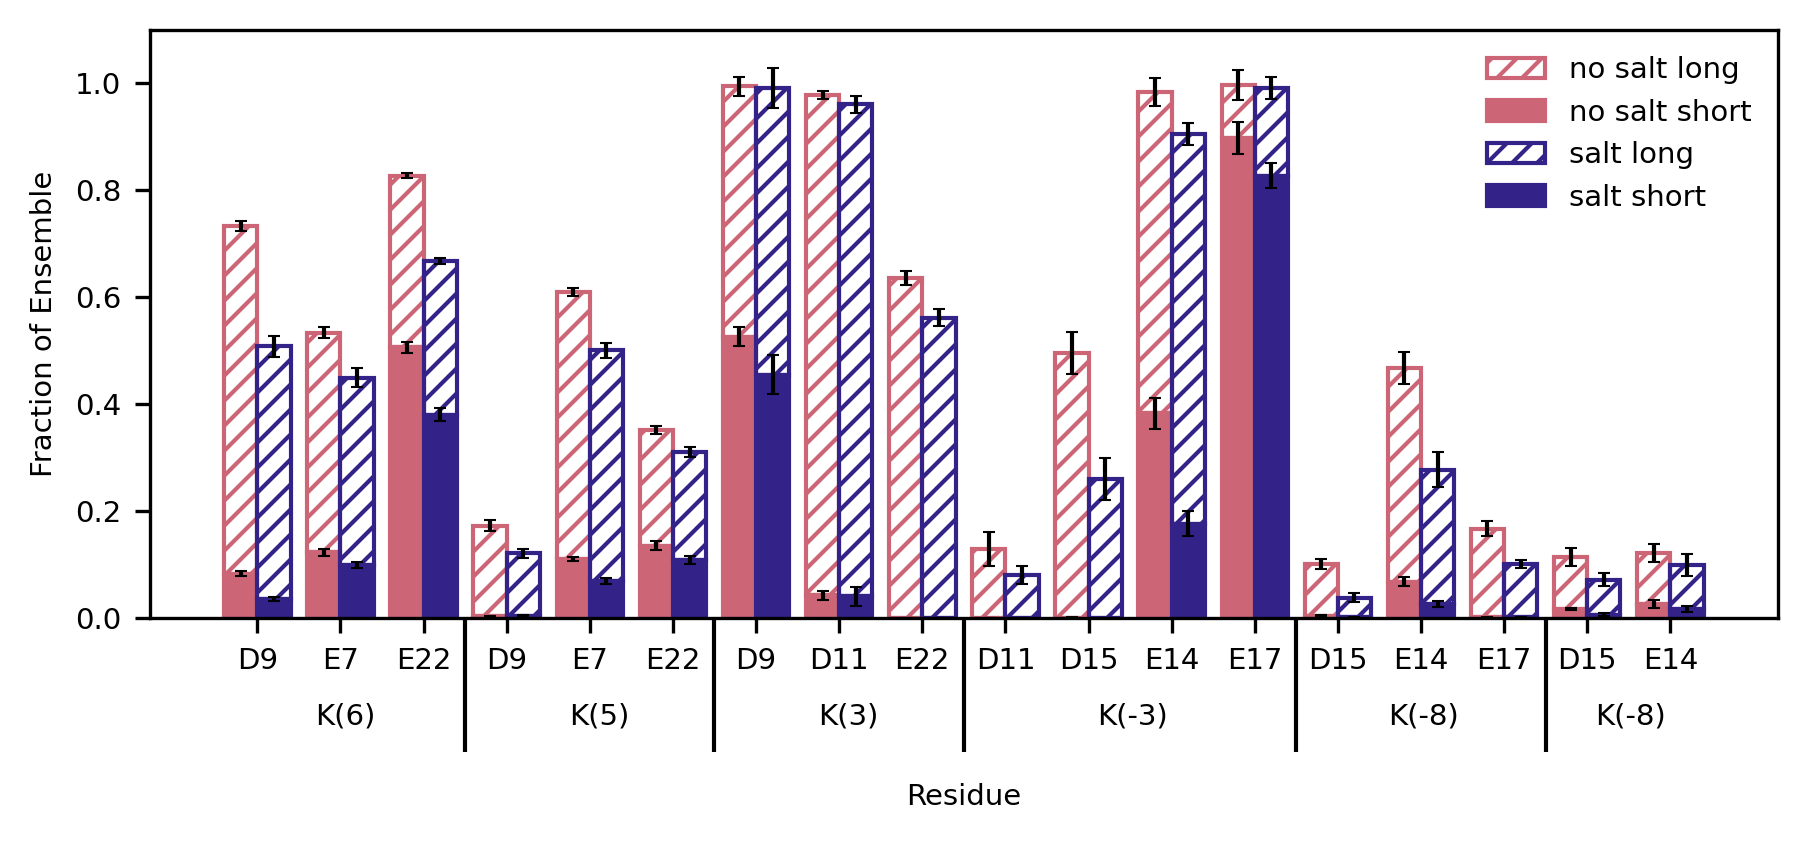

<Figure size 1100x400 with 0 Axes>

In [102]:
fig, ax = plt.subplots(dpi=300)
plt.rcParams['figure.figsize'] = [11, 4]

# Data
x = np.arange(len(electrostat_frac_subset_rn.dropna(axis=0).index))  # X coordinates for each group
width = 0.40  # Width of the bars

# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' long'], width, 
        bottom=electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' short'], edgecolor='#CC6677', facecolor='none', hatch='////', linewidth = 1,
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims1_label + ' long'], label=sims1_label + ' long', error_kw={'elinewidth': 1, "capsize": 1.5, "capthick": 0.5})

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims1_label + ' short'], width, edgecolor='#CC6677', color='#CC6677', linewidth = 1,
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims1_label + ' short'], label=sims1_label + ' short', error_kw={'elinewidth': 1, "capsize": 1.5, "capthick": 0.5})

# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' long'], width, 
        bottom=electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' short'], edgecolor='#332288', facecolor='none', hatch='////', linewidth = 1,
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims2_label + ' long'], label=sims2_label + ' long', error_kw={'elinewidth': 1, "capsize": 1.5, "capthick": 0.5})

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn.dropna(axis=0)[sims2_label + ' short'], width, edgecolor='#332288', color='#332288', linewidth = 1,
        yerr=electrostat_frac_sem_subset_rn.dropna(axis=0)[sims2_label + ' short'], label=sims2_label + ' short', error_kw={'elinewidth': 1, "capsize": 1.5, "capthick": 0.5})

# Set the y-axis limits
#plt.ylim(bottom=0, top=1.05)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=7, frameon=False)
#plt.xlabel('Residue', fontsize=7)                 
plt.ylabel('Fraction of Ensemble', fontsize=7)
# plt.title('Contact Between Charged Residues', fontsize=14)

# Set x-axis ticks as original index
plt.xticks(x, electrostat_frac_subset_rn.dropna(axis=0).index, fontsize=7)

plt.yticks(fontsize=7)

ymin = -0.25  
ymax = 0
ax.vlines(x=[2.5, 5.5, 8.5, 12.5, 15.5], ymin=ymin, ymax=ymax, 
          color='black', 
          linewidth=1, 
          clip_on=False)

plt.ylim(0, 1.1)

plt.text(7.8,-0.35, 'Residue', fontsize=7)

plt.text(0.7,-0.2, 'K(6)', fontsize=7)
plt.text(3.75,-0.2, 'K(5)', fontsize=7)
plt.text(6.75,-0.2, 'K(3)', fontsize=7)
plt.text(10.1,-0.2, 'K(-3)', fontsize=7)
plt.text(13.6,-0.2, 'K(-8)', fontsize=7)
plt.text(16.1,-0.2, 'K(-8)', fontsize=7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.show()
plt.savefig("electrostats_bound_ArkA17.png", dpi= 1000)

## Plot of average number of Electrostatic interaction

In [11]:
x = np.arange(1)  # X coordinates for each group
#print(x)
width = 0.25

plt.figure(figsize=(7,5))
#ax = total_electrostat_frac_bound.mean().plot.bar(yerr=total_electrostat_frac_bound.sem(), width=0.5, rot=45)
#fig = plt.gcf()
#ax.set_ylabel('Avg. # Electrostatic Interactions')
#plt.bar(x - width/2, total_electrostat_frac_bound.mean(), width, 
        #yerr=total_electrostat_frac_bound.sem())
    
# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - 3.015*width, total_electrostat_frac_bound['wild sims long'].mean(), width, 
        bottom=total_electrostat_frac_bound['wild sims short'].mean(), edgecolor='blue', facecolor='none', hatch='////', 
        yerr=total_electrostat_frac_bound['wild sims long'].sem(), label='wild sims long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - 3*width, total_electrostat_frac_bound['wild sims short'].mean(), width, color='blue',
        yerr=total_electrostat_frac_bound['wild sims short'].sem(), label='wild sims short')

plt.xlim(-1,1)
plt.ylim(0,15)
# Set x-axis ticks as original index
plt.xticks([x - 3.015*width , x - 1.0125*width,0.985*width, 2.985*width],["wildtype"], fontsize=14)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=10,frameon=False, )          
plt.ylabel('Avg. # of Electrostatic Interactions', fontsize=14)
plt.title('ArkA12 Bound', fontsize=18)

KeyError: 'wild sims long'

<Figure size 700x500 with 0 Axes>